# RL Network-Markowitz Portfolio Optimization
### Thesis-Ready Version — Multi-Seed SAC + Ablation Study (5000 Steps) + Comprehensive Dashboard

In [15]:
import os
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import networkx as nx
import seaborn as sns
import torch
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import SAC
from stable_baselines3.common.callbacks import BaseCallback
from tqdm.notebook import tqdm
from scipy import stats
from scipy.optimize import minimize
from IPython.display import Image, display

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

# ================================================================
# GLOBAL SETTINGS
# ================================================================
SEEDS         = [42, 123, 77]
TRAIN_STEPS   = 1000
FORCE_RETRAIN = True
GAMMA_CENTER  = 0
SET_WINDOW    = 30
SET_REBALANCE = 7
REWARD_WINDOW = 20
CVAR_LEVEL    = 0.95
STAT_ALPHA    = 0.05
SAVE_IMAGES   = True

MONITOR_START = 100
MONITOR_END   = 1000

ABLATION_CONFIGS = {
    'E2_Sharpe'          : {'use_network': True,  'use_market': True,  'extra_features': [], 'reward_type': 'sharpe'},
    'E2_Sortino'         : {'use_network': True,  'use_market': True,  'extra_features': [], 'reward_type': 'sortino'},
    'E2_Calmar'          : {'use_network': True,  'use_market': True,  'extra_features': [], 'reward_type': 'calmar'},
    'E2_Ulcer'           : {'use_network': True,  'use_market': True,  'extra_features': [], 'reward_type': 'ulcer'},
    'E2_Ensemble_Avg'    : {'use_network': True,  'use_market': True,  'extra_features': [], 'is_ensemble': True},
    'Comp_Static_Gamma0' : {'use_network': True,  'use_market': False, 'extra_features': [], 'static_gamma': 0.0},
    'Comp_Static_Gamma1' : {'use_network': True,  'use_market': False, 'extra_features': [], 'static_gamma': 1.0},
    'Comp_Static_Gamma2' : {'use_network': True,  'use_market': False, 'extra_features': [], 'static_gamma': 2.0},
}

EVAL_METRICS = ['Sharpe Ratio', 'Sortino Ratio', 'Calmar Ratio', 'Ulcer Index']
OUTPUT_DIR = os.path.join(os.getcwd(), 'ablation_results_thesis_5000')
os.makedirs(OUTPUT_DIR, exist_ok=True)

print('Environment initialized.')

Environment initialized.


In [16]:
file_data = 'crypto_data_real.xlsx'
def load_and_split(filename, train_split=0.7):
    df = pd.read_excel(filename, sheet_name='Returns', index_col=0)
    df.index = pd.to_datetime(df.index)
    assets = [c for c in df.columns if c != 'USDT']
    assets.sort()
    df = df[assets]
    split_idx = int(len(df) * train_split)
    return df.iloc[:split_idx], df.iloc[split_idx:], assets

ret_train, ret_test, assets = load_and_split(file_data)
print(f'Assets: {len(assets)} | Train: {len(ret_train)} | Test: {len(ret_test)}')

Assets: 9 | Train: 534 | Test: 229


In [17]:
def apply_rmt_filter(returns_window):
    T, N = returns_window.shape
    corr_mat = returns_window.corr().fillna(0).values
    eigenvalues, eigenvectors = np.linalg.eigh(corr_mat)
    Q = T / N
    l_max = (1 + np.sqrt(1/Q))**2
    eigenvalues[eigenvalues < l_max] = 0
    corr_denoised = eigenvectors @ np.diag(eigenvalues) @ eigenvectors.T
    np.fill_diagonal(corr_denoised, 1)
    return corr_denoised

def _solve_weights(cov_f, cent_vec, mu, gamma, n_assets):
    fun = lambda w: w.T @ cov_f @ w + gamma * np.sum(cent_vec * w)
    cons = (
        {'type': 'eq', 'fun': lambda w: np.sum(w) - 1},
        {'type': 'ineq', 'fun': lambda w: np.dot(w, mu) - np.mean(mu)}
    )
    w0 = np.ones(n_assets) / n_assets
    res = minimize(fun, w0, method='SLSQP', bounds=[(0, 1)]*n_assets, constraints=cons)
    return res.x if res.success else w0

def _build_mst_centrality(N, corr_f):
    dist = np.sqrt(np.maximum(0, 2*(1-corr_f)))
    G = nx.from_numpy_array(dist)
    mst = nx.minimum_spanning_tree(G)
    try:
        c = nx.eigenvector_centrality(mst, max_iter=300)
        cv = np.array([c[i] for i in range(N)])
    except:
        cv = np.array(list(nx.degree_centrality(mst).values()))
    return mst, cv

def fast_centrality_weights(cov_f, cent_vec, mu, gamma):
    return _solve_weights(cov_f, cent_vec, mu, gamma, len(mu))

def compute_classic_mv_weights(returns_window):
    mu = returns_window.mean().values
    cov = np.cov(returns_window.values.T) + np.eye(len(mu))*1e-8
    w0 = np.ones(len(mu)) / len(mu)
    res = minimize(lambda w: w@cov@w, w0, method='SLSQP', bounds=[(0,1)]*len(mu), 
                   constraints=[{'type': 'eq', 'fun': lambda w: np.sum(w)-1}])
    return res.x if res.success else w0

In [18]:
def _compute_drawdown(arr):
    cumulative = (1 + arr).cumprod()
    peak = np.maximum.accumulate(cumulative)
    dd = (cumulative - peak) / peak
    return dd, cumulative

def calculate_annualized_return(r, p=252):
    arr = np.array(r)
    if len(arr) == 0: return 0.0
    prod = (1+arr).prod()
    if prod <= 0: return -1.0
    return prod**(p/len(arr)) - 1

def calculate_sharpe_ratio(r, p=252):
    arr = np.array(r)
    ann = calculate_annualized_return(arr, p)
    vol = arr.std() * np.sqrt(p)
    return ann / vol if vol > 0 else 0.0

def calculate_sortino_ratio(r, p=252, m=0.0):
    arr = np.array(r)
    ann = calculate_annualized_return(arr, p)
    ds = arr[arr < m]
    dd = np.std(ds) * np.sqrt(p)
    return ann / dd if dd > 0 else 0.0

def calculate_calmar_ratio(r, p=252):
    arr = np.array(r)
    ann = calculate_annualized_return(arr, p)
    cum = (1 + arr).cumprod()
    pk = np.maximum.accumulate(cum)
    mdd = np.abs(((cum - pk) / pk).min())
    return ann / mdd if mdd > 1e-8 else 0.0

def calculate_ulcer_index(r):
    arr = np.array(r)
    if len(arr) == 0: return 0.0
    cum = (1 + arr).cumprod()
    pk = np.maximum.accumulate(cum)
    dd = (cum - pk) / pk
    return np.sqrt(np.mean(dd**2))

def calculate_all_metrics(r, p=252):
    return {
        'Sharpe Ratio': calculate_sharpe_ratio(r, p), 
        'Sortino Ratio': calculate_sortino_ratio(r, p), 
        'Calmar Ratio': calculate_calmar_ratio(r, p), 
        'Ulcer Index': calculate_ulcer_index(r)
    }

In [19]:
def compute_network_features(win):
    cf = apply_rmt_filter(win)
    mst, cv = _build_mst_centrality(win.shape[1], cf)
    dist = sum(d['weight'] for _,_,d in mst.edges(data=True))
    gap = nx.algebraic_connectivity(mst)
    return np.array([dist*0.1, gap], dtype=np.float32), cf, cv

def compute_market_features(win):
    arr = win.values
    v5, v20 = arr[-5:].std(axis=0).mean(), arr[-20:].std(axis=0).mean()
    m5, m20 = arr[-5:].mean(axis=0).mean(), arr[-20:].mean(axis=0).mean()
    pct_up = np.mean(arr[-5:].mean(axis=0) > arr[-20:].mean(axis=0))
    return np.array([v5*100, v20*100, v5/(v20+1e-8), m5*100, m20*100, (m5-m20)*100, pct_up], dtype=np.float32)

GLOBAL_CACHE = {}
print('Caching features...')
for i in range(SET_WINDOW, len(ret_train)):
    w = ret_train.iloc[i-SET_WINDOW:i]
    f, c, v = compute_network_features(w)
    GLOBAL_CACHE[i] = {'win': w, 'corr_f': c, 'cent_vec': v, 'cov_f': np.outer(w.std(), w.std())*c + np.eye(len(assets))*1e-8, 'mu': w.mean().values, 'nw_feat_full': f}

for i in range(SET_WINDOW, len(ret_test)):
    w = ret_test.iloc[i-SET_WINDOW:i]
    f, c, v = compute_network_features(w)
    GLOBAL_CACHE[len(ret_train)+i] = {'win': w, 'corr_f': c, 'cent_vec': v, 'cov_f': np.outer(w.std(), w.std())*c + np.eye(len(assets))*1e-8, 'mu': w.mean().values, 'nw_feat_full': f}

FEAT_MEAN = np.stack([GLOBAL_CACHE[i]['nw_feat_full'] for i in GLOBAL_CACHE if i < len(ret_train)]).mean(axis=0)
FEAT_STD  = np.stack([GLOBAL_CACHE[i]['nw_feat_full'] for i in GLOBAL_CACHE if i < len(ret_train)]).std(axis=0) + 1e-8

def build_observation(win, config, f_raw=None, c_f=None):
    if f_raw is None: f_raw, c_f, _ = compute_network_features(win)
    obs = []
    if config['use_network']: obs.append((f_raw - FEAT_MEAN)/FEAT_STD)
    if config['use_market']: obs.append(compute_market_features(win))
    return np.nan_to_num(np.concatenate(obs)), c_f

def get_obs_dim(config): return (2 if config['use_network'] else 0) + (7 if config['use_market'] else 0)

Caching features...


In [20]:
class AblationPortfolioEnv(gym.Env):
    def __init__(self, data, config, offset=0):
        super().__init__()
        self.data, self.config, self.offset = data, config, offset
        self.current_step, self.buffer = SET_WINDOW, []
        self.stats = {'mean': 0, 'M2': 0, 'count': 0}
        dim = max(get_obs_dim(config), 1)
        self.observation_space = spaces.Box(-np.inf, np.inf, (dim,))
        self.action_space = spaces.Box(-5.0, 5.0, (1,))

    def reset(self, seed=None, options=None):
        self.current_step, self.buffer = SET_WINDOW, []
        return self._get_obs(), {}

    def _get_obs(self):
        idx = self.offset + self.current_step
        c = GLOBAL_CACHE[idx]
        obs, _ = build_observation(c['win'], self.config, f_raw=c['nw_feat_full'], c_f=c['corr_f'])
        return obs

    def step(self, action):
        idx = self.offset + self.current_step
        c = GLOBAL_CACHE[idx]
        w = fast_centrality_weights(c['cov_f'], c['cent_vec'], c['mu'], float(action[0]))
        ret = np.dot(w, self.data.iloc[self.current_step].values)
        self.buffer.append(ret)
        if len(self.buffer) > REWARD_WINDOW: self.buffer.pop(0)
        
        rt = self.config.get('reward_type', 'calmar')
        arr = np.array(self.buffer)
        if len(arr) < 2:
            raw = ret * 100
        else:
            if rt == 'sharpe': raw = calculate_sharpe_ratio(arr)
            elif rt == 'sortino': raw = calculate_sortino_ratio(arr)
            elif rt == 'calmar': raw = calculate_calmar_ratio(arr)
            elif rt == 'ulcer':
                u = calculate_ulcer_index(arr)
                raw = calculate_annualized_return(arr) / u if u > 1e-8 else 0
            else: raw = 0
        
        s = self.stats; s['count'] += 1; d = raw - s['mean']; s['mean'] += d / s['count']; s['M2'] += d * (raw - s['mean'])
        std = np.sqrt(s['M2'] / s['count']) if s['count'] > 1 else 1.0
        reward = np.clip(raw / (std + 1e-6), -10, 10)
        
        self.current_step += 1
        done = self.current_step >= len(self.data) - 1
        obs = self._get_obs() if not done else np.zeros(self.observation_space.shape)
        return obs, float(reward), done, False, {}

class RewardLoggerCallback(BaseCallback):
    def __init__(self, verbose=0):
        super().__init__(verbose)
        self.ep_rewards, self.step_rewards, self.cur = [], [], 0
    
    def _on_step(self) -> bool:
        r = self.locals['rewards'][0]
        self.step_rewards.append(r)
        self.cur += r
        if self.locals['dones'][0]:
            self.ep_rewards.append(self.cur)
            self.cur = 0
        return True

def plot_step_monitoring(rewards, exp_id, start, end):
    plt.figure(figsize=(10, 4))
    slice_data = rewards[start:end]
    steps = range(start, start + len(slice_data))
    cm = {'E2_Sharpe': '#FF9800', 'E2_Sortino': '#9C27B0', 'E2_Calmar': '#2196F3', 'E2_Ulcer': '#F44336'}
    plt.plot(steps, slice_data, color=cm.get(exp_id, '#4CAF50'), alpha=0.5, label='Raw Step Reward')
    if len(slice_data) > 20:
        plt.plot(steps, pd.Series(slice_data).rolling(20).mean(), color='black', lw=2, label='Trend')
    plt.title(f'Monitoring {exp_id} (Steps {start}-{end})')
    plt.legend(); plt.show()

Training:   0%|          | 0/8 [00:00<?, ?it/s]

Output()

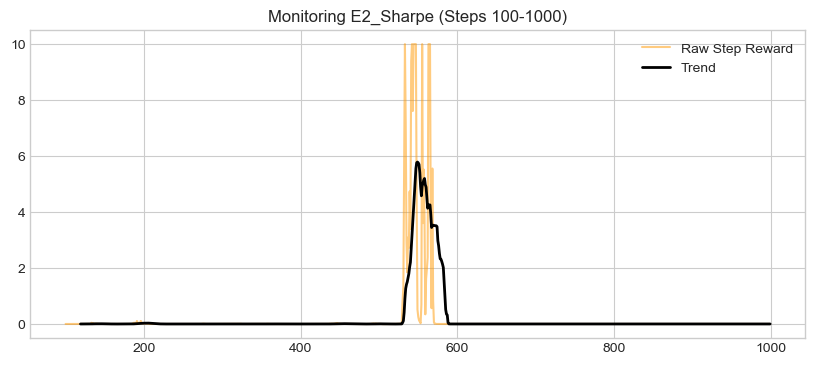

Output()

Output()

Output()

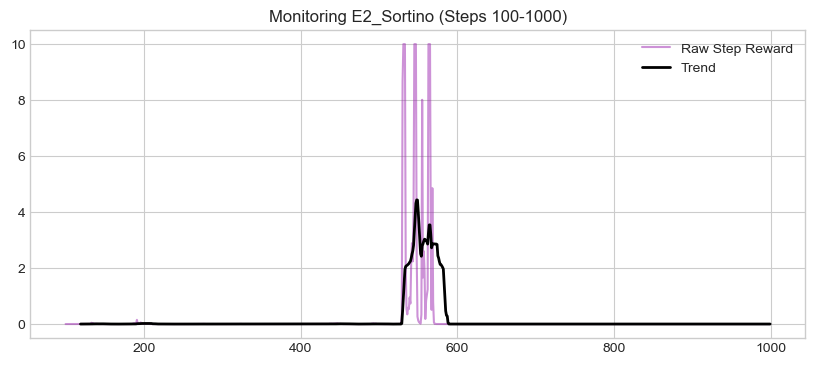

Output()

Output()

Output()

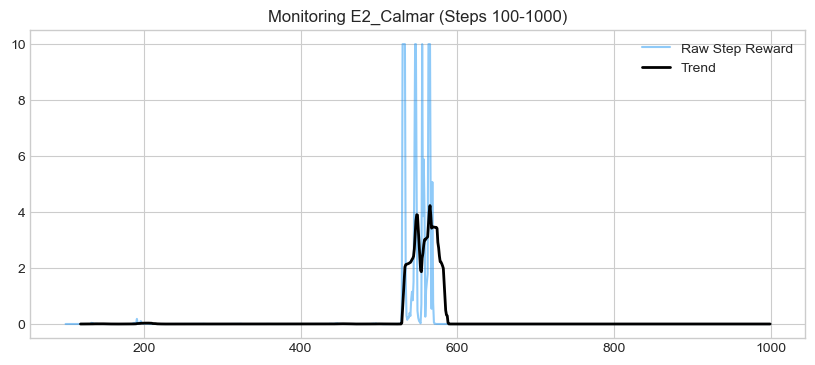

Output()

Output()

Output()

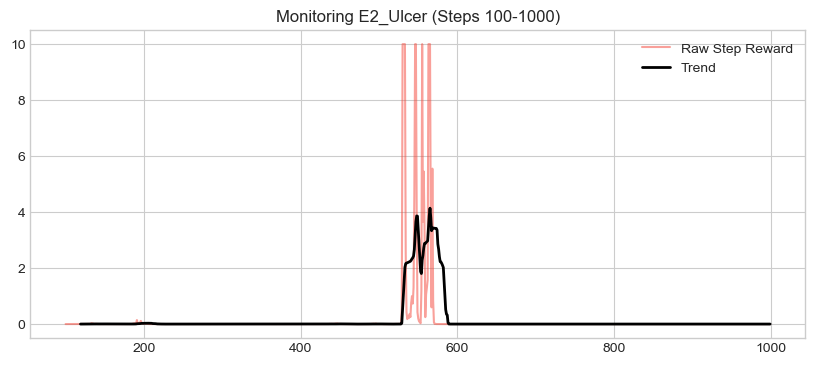

Output()

Output()

In [21]:
trained_models, train_histories = {}, {}
for exp_id, config in tqdm(ABLATION_CONFIGS.items(), desc="Training"):
    if config.get('static_gamma') is not None or config.get('is_ensemble'): continue
    train_histories[exp_id] = {}
    for seed in SEEDS:
        name = f'model_{exp_id}_s{seed}'
        if os.path.exists(name + ".zip") and not FORCE_RETRAIN:
            trained_models[(exp_id, seed)] = name
            continue
        env = AblationPortfolioEnv(ret_train, config)
        cb = RewardLoggerCallback()
        model = SAC('MlpPolicy', env, seed=seed, verbose=0, learning_rate=3e-4)
        model.learn(total_timesteps=TRAIN_STEPS, callback=cb, progress_bar=True)
        model.save(name)
        trained_models[(exp_id, seed)] = name
        train_histories[exp_id][seed] = cb.ep_rewards
        if seed == SEEDS[0]:
            plot_step_monitoring(cb.step_rewards, exp_id, MONITOR_START, MONITOR_END)

In [22]:
results_test = {}
for exp_id in list(ABLATION_CONFIGS.keys()) + ['Classic-MV']:
    results_test[exp_id] = pd.DataFrame()
    config = ABLATION_CONFIGS.get(exp_id, {})
    for seed in SEEDS:
        rets = []
        if exp_id == 'Classic-MV':
            for i in range(SET_WINDOW, len(ret_test)):
                w = compute_classic_mv_weights(GLOBAL_CACHE[len(ret_train)+i]['win'])
                rets.append(np.dot(w, ret_test.iloc[i].values))
        elif config.get('static_gamma') is not None:
            for i in range(SET_WINDOW, len(ret_test)):
                c = GLOBAL_CACHE[len(ret_train)+i]
                w = fast_centrality_weights(c['cov_f'], c['cent_vec'], c['mu'], config['static_gamma'])
                rets.append(np.dot(w, ret_test.iloc[i].values))
        else:
            if config.get('is_ensemble'):
                models = [SAC.load(trained_models[(m, seed)]) for m in ['E2_Sharpe','E2_Sortino','E2_Calmar','E2_Ulcer']]
            else:
                models = [SAC.load(trained_models[(exp_id, seed)])]
            
            for i in range(SET_WINDOW, len(ret_test)):
                c = GLOBAL_CACHE[len(ret_train)+i]
                obs, _ = build_observation(c['win'], config, c['nw_feat_full'], c['corr_f'])
                gammas = [float(m.predict(obs, deterministic=True)[0][0]) for m in models]
                w = fast_centrality_weights(c['cov_f'], c['cent_vec'], c['mu'], np.mean(gammas))
                rets.append(np.dot(w, ret_test.iloc[i].values))
        results_test[exp_id][seed] = pd.Series(rets, index=ret_test.index[SET_WINDOW:])
print('Backtesting complete.')

Backtesting complete.


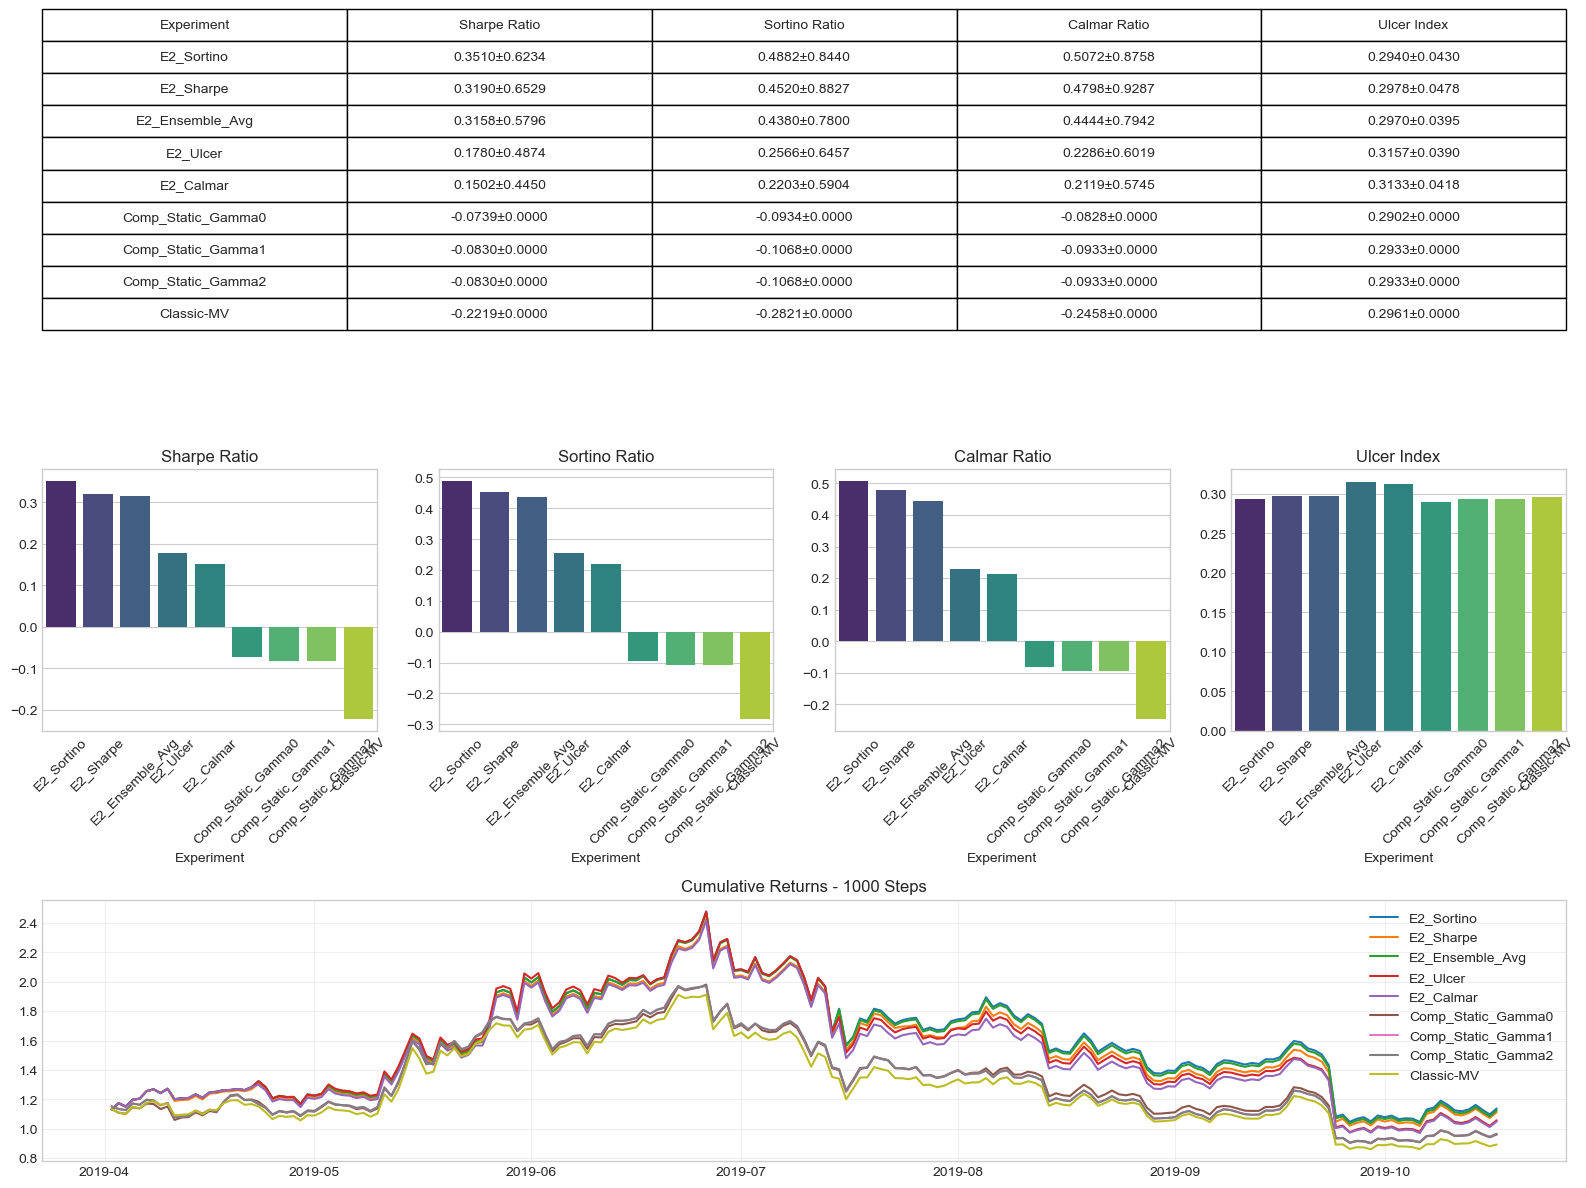

In [23]:
def create_ablation_dashboard(results, title_suffix=""):
    summary = []
    for exp_id, df in results.items():
        metrics_seeds = [calculate_all_metrics(df[s]) for s in df.columns]
        row = {'Experiment': exp_id}
        for m in EVAL_METRICS:
            vals = [ms[m] for ms in metrics_seeds]
            row[m] = f"{np.mean(vals):.4f}±{np.std(vals):.4f}"
        summary.append(row)
    
    df_sum = pd.DataFrame(summary)
    # Sort based on first metric for ranking
    df_sum['rank_val'] = df_sum['Sharpe Ratio'].apply(lambda x: float(x.split('±')[0]))
    df_sum = df_sum.sort_values('rank_val', ascending=False).drop('rank_val', axis=1)
    
    fig = plt.figure(figsize=(16, 12))
    gs = gridspec.GridSpec(3, 4, figure=fig)
    
    ax_table = fig.add_subplot(gs[0, :])
    ax_table.axis('off')
    table = ax_table.table(cellText=df_sum.values, colLabels=df_sum.columns, loc='center', cellLoc='center')
    table.auto_set_font_size(False); table.set_fontsize(10); table.scale(1, 2)
    
    for i, m in enumerate(EVAL_METRICS):
        ax = fig.add_subplot(gs[1, i])
        means = []
        for eid in df_sum['Experiment']:
            vals = [calculate_all_metrics(results[eid][s])[m] for s in results[eid].columns]
            means.append(np.mean(vals))
        sns.barplot(x=df_sum['Experiment'], y=means, ax=ax, palette='viridis')
        ax.set_title(m); ax.tick_params(axis='x', rotation=45)
        
    ax_cum = fig.add_subplot(gs[2, :])
    for eid in df_sum['Experiment']:
        cum = (1 + results[eid].mean(axis=1)).cumprod()
        ax_cum.plot(cum, label=eid)
    ax_cum.set_title(f'Cumulative Returns - {title_suffix}')
    ax_cum.legend(); ax_cum.grid(True, alpha=0.3)
    
    plt.tight_layout()
    if SAVE_IMAGES:
        plt.savefig(os.path.join(OUTPUT_DIR, 'ablation_dashboard.png'), dpi=150)
    plt.show()

create_ablation_dashboard(results_test, f"{TRAIN_STEPS} Steps")